### Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.interpolate import CubicSpline
from numpy.polynomial.legendre import leggauss

In [ ]:
# ==========================================
# Interpolation Tables (External Data)
# ==========================================
# Read Chandrasekhar (1960) tables from an external CSV file

try:
    table_data = np.loadtxt("chandrasekhar_1960.csv", delimiter=",", skiprows=1)
except FileNotFoundError:
    raise FileNotFoundError("Please ensure 'chandrasekhar_1960.csv' is in the same directory.")

mu_table = table_data[:, 0]
I_l_table = table_data[:, 1]
I_r_table = table_data[:, 2]

I_l_spline = CubicSpline(mu_table, I_l_table)
I_r_spline = CubicSpline(mu_table, I_r_table)

In [ ]:
# Integration grids
N_THETA = 256
N_PHI = 256

dPhi = 2 * np.pi / N_PHI
u, w_Theta = leggauss(N_THETA)

Theta_list = np.arccos(u)
Phi_list = (np.arange(N_PHI) + 0.5) * dPhi
Theta_grid, Phi_grid = np.meshgrid(Theta_list, Phi_list, indexing='ij')

sin_Theta = np.sin(Theta_grid)
cos_Theta = np.cos(Theta_grid)
sin_Phi = np.sin(Phi_grid)
cos_Phi = np.cos(Phi_grid)

# Cartesian coordinates on the unit sphere
x_sphere = sin_Theta * cos_Phi
y_sphere = sin_Theta * sin_Phi
z_sphere = cos_Theta

w_Theta_array = np.tile(w_Theta[:, np.newaxis], (1, N_PHI))

In [ ]:
# ==========================================
# Helper Functions
# ==========================================

def I_prime(mu):
    """
    Calculate the total specific intensity (I_l + I_r) for a given cosine of emission angle.
    """
    return I_l_spline(mu) + I_r_spline(mu)

def Q_prime(mu, cos_2psi):
    """
    Calculate the Stokes Q parameter component before integration.
    """
    return (I_l_spline(mu) - I_r_spline(mu)) * cos_2psi

def U_prime(mu, sin_2psi):
    """
    Calculate the Stokes U parameter component before integration.
    """
    return (I_l_spline(mu) - I_r_spline(mu)) * sin_2psi

def get_x_prime(theta, phi):
    """
    Compute the x-prime basis vector (line of sight) given viewing angles.
    """
    xx = np.sin(theta) * np.cos(phi)
    xy = np.sin(theta) * np.sin(phi)
    xz = np.cos(theta)
    return np.array([xx, xy, xz])

def get_y_prime(phi):
    """
    Compute the y-prime basis vector given the azimuthal viewing angle.
    """
    yx = -np.sin(phi)
    yy = np.cos(phi)
    yz = 0.0
    return np.array([yx, yy, yz])

def get_z_prime(theta, phi):
    """
    Compute the z-prime basis vector given viewing angles.
    """
    zx = -np.cos(theta) * np.cos(phi)
    zy = -np.cos(theta) * np.sin(phi)
    zz = np.sin(theta)
    return np.array([zx, zy, zz])

def get_mu_array(n_array, x_prime):
    """
    Calculate the cosine of the angle between the local normal and the viewing direction.
    """
    xx, xy, xz = x_prime
    nx, ny, nz = n_array
    return xx*nx + xy*ny + xz*nz

def get_r2_array(a, b, sin_T, cos_T, sin_P, cos_P):
    """
    Calculate the inverse squared distance to the origin on the ellipsoid surface.
    """
    s = sin_T * cos_P / a
    t = sin_T * sin_P / b
    u = cos_T
    return 1.0 / (s**2 + t**2 + u**2)

def get_w_array(r2_array, n_array, x_s, y_s, z_s):
    """
    Calculate the projected area weight for surface integration.
    """
    nx, ny, nz = n_array
    nr_array = nx*x_s + ny*y_s + nz*z_s
    epsilon = 1e-12
    return r2_array / np.maximum(np.abs(nr_array), epsilon)

def get_psi_array(n_array, y_prime, z_prime):
    """
    Calculate trigonometric components (cos(2*psi), sin(2*psi)) of the polarization rotation angle.
    """
    yx, yy, yz = y_prime
    zx, zy, zz = z_prime
    nx, ny, nz = n_array

    ny_prime = yx*nx + yy*ny + yz*nz
    nz_prime = zx*nx + zy*ny + zz*nz
    den = nz_prime**2 + ny_prime**2
    epsilon = 1e-12

    mask = (den > epsilon)
    cos_2phi = np.zeros_like(den)
    sin_2phi = np.zeros_like(den)
    cos_2phi[mask] = (nz_prime[mask]**2 - ny_prime[mask]**2) / den[mask]
    sin_2phi[mask] = 2 * ny_prime[mask] * nz_prime[mask] / den[mask]
    return cos_2phi, sin_2phi

def integrate_all_parameters(a, b, theta, phi, n_array, r2_array, w_Theta_arr, d_Phi, x_s, y_s, z_s):
    """
    Perform numerical integration over the visible, illuminated ellipsoid surface
    to compute net Stokes parameters (I, Q, U).
    """
    x_prime = get_x_prime(theta, phi)
    y_prime = get_y_prime(phi)
    z_prime = get_z_prime(theta, phi)

    mu_array = get_mu_array(n_array, x_prime)
    mu_masked = np.maximum(mu_array, 0.0)
    w_array = get_w_array(r2_array, n_array, x_s, y_s, z_s)
    w_p_array = mu_masked * w_array
    cos_2psi, sin_2psi = get_psi_array(n_array, y_prime, z_prime)

    # Common integration weight factor
    int_weight = w_p_array * w_Theta_arr * d_Phi

    I_net = np.sum(int_weight * I_prime(mu_masked))
    Q_net = np.sum(int_weight * Q_prime(mu_masked, cos_2psi))
    U_net = np.sum(int_weight * U_prime(mu_masked, sin_2psi))

    return I_net, Q_net, U_net

def get_Pi(I_net, Q_net, U_net):
    """
    Calculate the degree of polarization in percentage.
    """
    return np.sqrt(Q_net**2 + U_net**2) / I_net * 100

def get_chi(Q_net, U_net):
    """
    Calculate the polarization angle (position angle) in radians.
    """
    return 0.5 * np.arctan2(U_net, Q_net)

### Figure 2 : The degree of polarization of oblate spheroids for different viewing angle

Computing for log(a) = 0.25 ...
Computing for log(a) = 0.50 ...
Computing for log(a) = 0.75 ...
Computing for log(a) = 1.00 ...


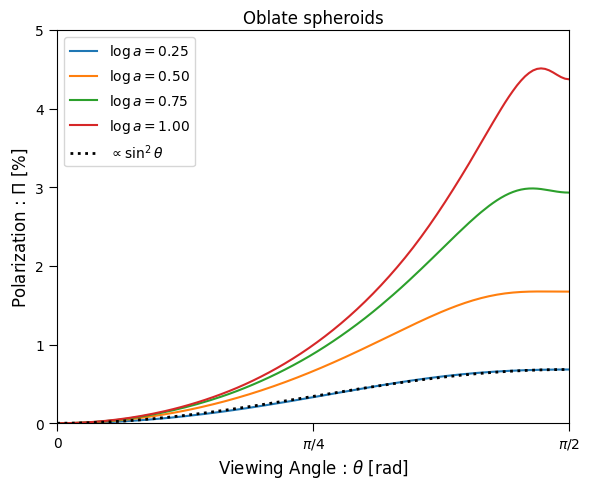

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

#Axis ratio grids
log_a_list = np.array([0.25, 0.50, 0.75, 1.00])

#Viewing angle grids
theta_list = np.linspace(0, np.pi/2, 129)

C_model = 0.0

for i, log_a in enumerate(log_a_list):
    a = 10**log_a
    b = a  # Axisymmetric spheroids

    print(f"Computing for log(a) = {log_a:.2f} ...")

    # Calculate geometric arrays for the current spheroid shape
    nx = sin_Theta * cos_Phi / a**2
    ny = sin_Theta * sin_Phi / b**2
    nz = cos_Theta
    n_array = np.stack([nx, ny, nz], axis=0)

    norm = np.linalg.norm(n_array, axis=0, keepdims=True)
    n_array /= np.maximum(norm, 1e-12)

    r2_array = 1.0 / ((sin_Theta * cos_Phi / a)**2 +
                      (sin_Theta * sin_Phi / b)**2 +
                      cos_Theta**2)

    # Compute polarization across the viewing angle theta_list
    Pi_list = []
    for theta_val in theta_list:
        I, Q, U = integrate_all_parameters(
        a, b, theta_val, 0.0,
        n_array, r2_array,
        w_Theta_array, dPhi,
        x_sphere, y_sphere, z_sphere
        )
        Pi_list.append(get_Pi(I, Q, U))

    # Plot the result
    ax.plot(theta_list, Pi_list, lw=1.5, label=fr"$\log a = {log_a:.2f}$")

    # Capture the edge-on polarization value for the reference model
    if i == 0:
        C_model = Pi_list[-1]

# Plot the theoretical reference model: Pi proportional to sin^2(theta)
Pi_model = C_model * (np.sin(theta_list))**2
ax.plot(theta_list, Pi_model, lw=2.0, color="black", linestyle=":", label=r"$\propto \sin^2\theta$")

# Plot Aesthetics
ax.set_xlabel(r"Viewing Angle : $\theta$ [rad]", fontsize=12)
ax.set_ylabel(r"Polarization : $\Pi$ [%]", fontsize=12)
ax.set_xlim(0.0, np.pi/2)
ax.set_ylim(0.0, 5.0)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.tick_params(axis='both', which='major', labelsize=10, length=6)
ax.set_title("Oblate spheroids", fontsize=12, pad=5)
ax.legend(fontsize=10, loc="best")

plt.tight_layout()
plt.show()

### Figure 3 : The degree of polarization of prolate spheroids for different viewing angle

In [153]:
I0, I1, Q0 = 0.442, 0.837, 0.0424

def compute_cylinder_polarization(a, theta):
    """
    Computes polarization degree Pi [%] for a cylinder with radius 'a'
    at viewing angle 'theta' [rad] based on the analytical model.
    Vectorized for numpy arrays.
    """
    # Safeguard for trig functions to avoid division by zero
    sin_t = np.maximum(np.sin(theta), 1e-12)
    cos_t = np.cos(theta)
    sin2_t = np.maximum(sin_t**2, 1e-12)

    # --- Top contributions ---
    # Based on the intensity distribution (I0 + I1*mu)*mu
    i_top = np.pi * a**2 * (I0 + I1 * cos_t) * cos_t
    q_top = np.pi * a**2 * (Q0 * (cos_t - 1.0)) * cos_t

    # --- Side contributions ---
    i_side = 4 * a * sin_t * (I0 + np.pi * I1 / 4.0 * sin_t)

    # Q side calculation using geometric terms
    term1 = (cos_t / sin2_t) * (np.pi * (1.0 - cos_t) - 2.0 * theta)
    term2 = ((1.0 + cos_t**2) / sin_t) * (1.0 - np.pi / 4.0 * sin_t)

    q_side = 4 * a * Q0 * (term1 + term2)
    q_side = np.where(sin2_t > 1e-12, q_side, np.nan)

    # --- Net Stokes Parameters ---
    i_net = i_top + i_side
    q_net = q_top + q_side

    # Calculate Pi [%]
    return np.abs(q_net) / i_net * 100.0

def compute_limit_polarization(theta):
    """
    Computes the polarization degree Pi [%] in the limit as a -> 0
    (the extreme cylindrical limit) at viewing angle 'theta' [rad].

    Vectorized for numpy arrays.
    """
    # Safeguard for trigonometric functions
    sin_t = np.sin(theta)
    cos_t = np.cos(theta)

    # Precompute denominator terms for numerical stability
    # Using epsilon to avoid division by zero at theta = 0, pi/2
    sin2_t = np.maximum(sin_t**2, 1e-12)
    sin3_t = np.maximum(sin_t**3, 1e-12)

    # Net Intensity (I_net)
    i_net = (np.pi / 2.0) * I1 * sin_t + 2.0 * I0

    # Net Polarization (Q_net)
    # The term (1 + cos(theta)^2) / sin(theta)^2 is equivalent to (1 + cos^2)/sin^2
    term1 = (np.pi / 4.0) * (1.0 - 2.0 / (1.0 + cos_t)**2) * sin_t
    term2 = (1.0 + cos_t**2) / sin2_t
    term3 = -2.0 * theta * cos_t / sin3_t

    q_net = 2.0 * Q0 * (term1 + term2 + term3)

    # Handle singularity at theta = 0 (limit is finite)
    # At theta -> 0, Pi -> 0 due to symmetry.
    pi_val = np.abs(q_net) / i_net * 100.0
    return np.where(theta > 1e-6, pi_val, np.nan)

Computing for log(a) = -0.20 ...
Computing for log(a) = -0.60 ...
Computing for log(a) = -1.00 ...
Computing for log(a) = -2.00 ...


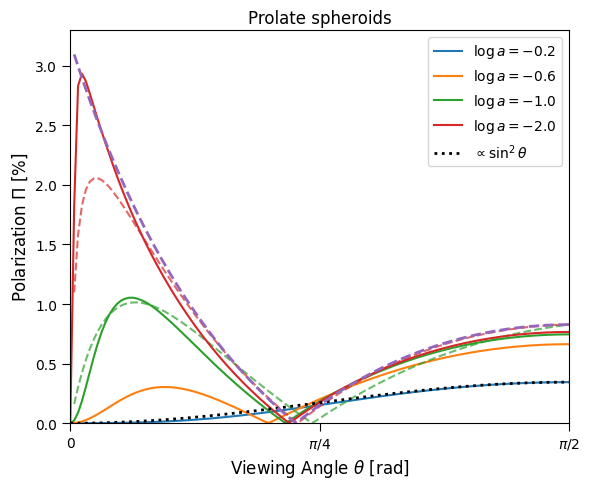

In [154]:
fig, ax = plt.subplots(figsize=(6, 5))

colors = ["C0", "C1", "C2", "C3", "C4", "C5"]

# Axis ratio grids
log_a_list = np.array([-0.20, -0.60, -1.00, -2.00])

# Viewing angle grids
theta_list = np.linspace(0, np.pi/2, 129)

C_model = 0.0

for i, log_a in enumerate(log_a_list):
    a = 10**log_a
    b = a  # Axisymmetric spheroids

    print(f"Computing for log(a) = {log_a:.2f} ...")

    # 1. Ellipsoid Calculation (Spheroid geometry)
    nx = sin_Theta * cos_Phi / a**2
    ny = sin_Theta * sin_Phi / b**2
    nz = cos_Theta
    n_array = np.stack([nx, ny, nz], axis=0)
    n_array /= np.maximum(np.linalg.norm(n_array, axis=0, keepdims=True), 1e-12)

    r2_array = 1.0 / ((sin_Theta * cos_Phi / a)**2 +
                      (sin_Theta * sin_Phi / b)**2 +
                      cos_Theta**2)

    Pi_list = []
    for theta_val in theta_list:
        I, Q, U = integrate_all_parameters(
        a, b, theta_val, 0.0,
        n_array, r2_array,
        w_Theta_array, dPhi,
        x_sphere, y_sphere, z_sphere
        )
        Pi_list.append(get_Pi(I, Q, U))

    ax.plot(theta_list, Pi_list, c=colors[i], lw=1.5, label=fr"$\log a = {log_a:.1f}$")

    # 2. Cylindrical Approximation Overlay (for extreme cases)
    if log_a <= -1.0:
        Pi_analytic = compute_cylinder_polarization(a, theta_list)
        ax.plot(theta_list, Pi_analytic, c=colors[i], lw=1.5, ls="--", alpha=0.7)

    # 3. Store edge-on value for reference model
    if i == 0:
        C_model = Pi_list[-1]

# 4. Reference model: sin^2(theta)
Pi_model = C_model * (np.sin(theta_list))**2
ax.plot(theta_list, Pi_model, lw=2.0, color="black", linestyle=":", label=r"$\propto \sin^2\theta$")

#5. Cylindal Approximation Overlay (the limit as a approaches 0)
Pi_limit = compute_limit_polarization(theta_list)
plt.plot(theta_list, Pi_limit, c=colors[4], lw=2.0, ls="--")

# Aesthetic settings
ax.set_xlabel(r"Viewing Angle $\theta$ [rad]", fontsize=12)
ax.set_ylabel(r"Polarization $\Pi$ [%]", fontsize=12)
ax.set_xlim(0.0, np.pi/2)
ax.set_ylim(0.0, 3.3)
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.tick_params(axis='both', which='major', labelsize=10, length=6)
ax.set_title("Prolate spheroids", fontsize=12, pad=5)
ax.legend(fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

### Figure 4. The distribution of polarization degree for various viewing angles and axis ratios

### Oblate spheroids

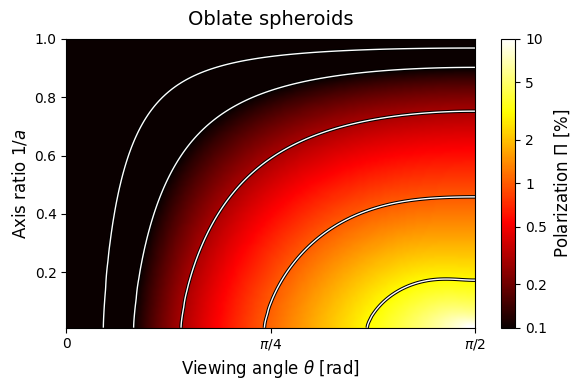

In [141]:
# ==========================================
# 1. Data Loading and Preparation
# ==========================================
# Load the pre-computed polarization data from the CSV file.
# Note: df_pi.index represents the viewing angle (theta),
# and df_pi.columns represents the axis ratio (1/a).
df_pi = pd.read_csv('spheroid_map_oblate.csv', index_col=0, encoding='utf-8-sig')

# Transpose the data matrix so that the x-axis corresponds to theta
# and the y-axis corresponds to the axis ratio 'a'.
plot_data = df_pi.values.T

# Extract the coordinate arrays
a_inverse_list = df_pi.columns.astype(float).values
theta_list = df_pi.index.astype(float).values

# Define the bounding box for the image: [x_min, x_max, y_min, y_max].
# This alignment ensures the heatmap pixels exactly match the physical coordinates.
extent = [theta_list.min(), theta_list.max(), a_inverse_list.min(), a_inverse_list.max()]

# ==========================================
# 2. Visualization Setup
# ==========================================
fig, ax = plt.subplots(figsize=(6, 4))

# Plot the 2D heatmap. We use log10(data + epsilon) to handle values close to zero.
# 'origin="lower"' ensures the y-axis starts from the minimum value at the bottom.
# 'interpolation="bilinear"' provides a smooth, continuous gradient suitable for publications.
im = ax.imshow(np.log10(plot_data + 1e-10),
               origin="lower",
               extent=extent,
               cmap="hot",
               vmin=-1.0, vmax=1.0,
               aspect="auto",
               interpolation="bilinear")

# ==========================================
# 3. Contour Overlay
# ==========================================
# Create a 2D meshgrid for plotting the contour lines.
Mesh_X, Mesh_Y = np.meshgrid(theta_list, a_inverse_list)

# Define the specific polarization levels [%] to be highlighted with contours.
levels = [0.03, 0.1, 0.3, 1.0, 3.0]

# Draw double contours (a black base with a thinner white overlay).
# This technique ensures the contour lines remain highly visible against both dark and bright backgrounds.
ax.contour(Mesh_X, Mesh_Y, plot_data, colors='black', linewidths=2.5, levels=levels)
ax.contour(Mesh_X, Mesh_Y, plot_data, colors='white', linewidths=1.0, levels=levels)

# ==========================================
# 4. Axes Formatting
# ==========================================
# Format the x-axis (Viewing Angle) with radians and proper LaTeX symbols.
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.set_xlabel(r'Viewing angle $\theta$ [rad]', fontsize=12)

# Format the y-axis (Axis Ratio).
ax.set_ylabel(r'Axis ratio $1/a$', fontsize=12)

ax.tick_params(axis="both", labelsize=10)
ax.set_title("Oblate spheroids", fontsize=14, pad=10)

# ==========================================
# 5. Colorbar Configuration
# ==========================================
# Attach a colorbar aligned with the heatmap.
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'Polarization $\Pi$ [%]', fontsize=12)

# Map the log10 tick positions back to readable percentage labels.
cbar.set_ticks([-1, -0.7, -0.3, 0, 0.3, 0.7, 1])
cbar.set_ticklabels(['0.1', '0.2', '0.5', '1', '2', '5', '10'])

# Finalize the layout and display the plot.
plt.tight_layout()
plt.show()

### Prolate spheroids

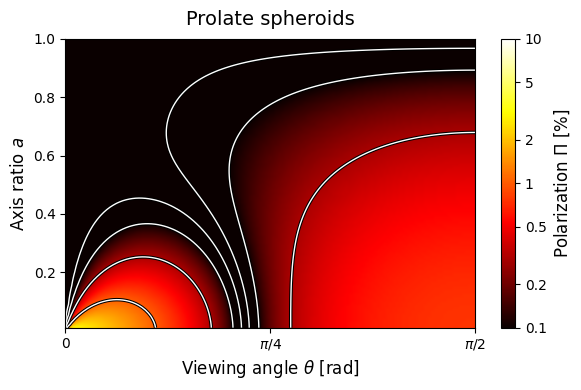

In [142]:
# ==========================================
# 1. Data Loading and Preparation
# ==========================================
# Load the pre-computed polarization data from the CSV file.
# Note: df_pi.index represents the viewing angle (theta),
# and df_pi.columns represents the axis ratio (a).
df_pi = pd.read_csv('spheroid_map_prolate.csv', index_col=0, encoding='utf-8-sig')

# Transpose the data matrix so that the x-axis corresponds to theta
# and the y-axis corresponds to the axis ratio 'a'.
plot_data = df_pi.values.T

# Extract the coordinate arrays
a_list = df_pi.columns.astype(float).values
theta_list = df_pi.index.astype(float).values

# Define the bounding box for the image: [x_min, x_max, y_min, y_max].
# This alignment ensures the heatmap pixels exactly match the physical coordinates.
extent = [theta_list.min(), theta_list.max(), a_list.min(), a_list.max()]

# ==========================================
# 2. Visualization Setup
# ==========================================
fig, ax = plt.subplots(figsize=(6, 4))

# Plot the 2D heatmap. We use log10(data + epsilon) to handle values close to zero.
# 'origin="lower"' ensures the y-axis starts from the minimum value at the bottom.
# 'interpolation="bilinear"' provides a smooth, continuous gradient suitable for publications.
im = ax.imshow(np.log10(plot_data + 1e-10),
               origin="lower",
               extent=extent,
               cmap="hot",
               vmin=-1.0, vmax=1.0,
               aspect="auto",
               interpolation="bilinear")

# ==========================================
# 3. Contour Overlay
# ==========================================
# Create a 2D meshgrid for plotting the contour lines.
Mesh_X, Mesh_Y = np.meshgrid(theta_list, a_list)

# Define the specific polarization levels [%] to be highlighted with contours.
levels = [0.03, 0.1, 0.3, 1.0, 3.0]

# Draw double contours (a black base with a thinner white overlay).
# This technique ensures the contour lines remain highly visible against both dark and bright backgrounds.
ax.contour(Mesh_X, Mesh_Y, plot_data, colors='black', linewidths=2.5, levels=levels)
ax.contour(Mesh_X, Mesh_Y, plot_data, colors='white', linewidths=1.0, levels=levels)

# ==========================================
# 4. Axes Formatting
# ==========================================
# Format the x-axis (Viewing Angle) with radians and proper LaTeX symbols.
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
ax.set_xlabel(r'Viewing angle $\theta$ [rad]', fontsize=12)

# Format the y-axis (Axis Ratio).
ax.set_ylabel(r'Axis ratio $a$', fontsize=12)

ax.tick_params(axis="both", labelsize=10)
ax.set_title("Prolate spheroids", fontsize=14, pad=10)

# ==========================================
# 5. Colorbar Configuration
# ==========================================
# Attach a colorbar aligned with the heatmap.
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'Polarization $\Pi$ [%]', fontsize=12)

# Map the log10 tick positions back to readable percentage labels.
cbar.set_ticks([-1, -0.7, -0.3, 0, 0.3, 0.7, 1])
cbar.set_ticklabels(['0.1', '0.2', '0.5', '1', '2', '5', '10'])

# Finalize the layout and display the plot.
plt.tight_layout()
plt.show()

### Figure 5 : The polarization degree of an ellipsoid with log a = 0.5 and log b = -0.5 for different viewing angles

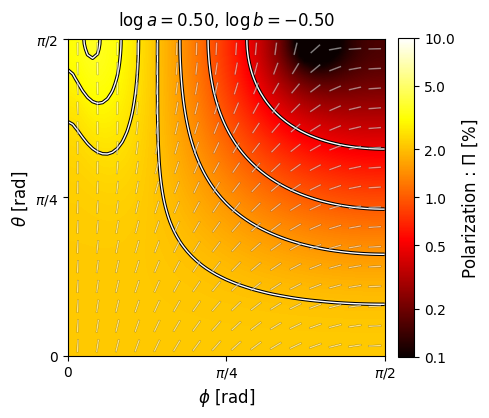

In [146]:
# ==========================================
# 1. Data Loading & Parameter Selection
# ==========================================
filename = "ellipsoid_polarization_db_small.h5"

with h5py.File(filename, "r") as f:
    log_a_list = f["grid/log_a"][:]
    log_b_list = f["grid/log_b"][:]
    theta = f["grid/theta"][:]
    phi = f["grid/phi"][:]
    pi_data = f["Pi/values"][:]
    chi_data = f["chi/values"][:]

# Specify the target indices for the semi-axes
ia, ib = 3, 1
current_log_a = log_a_list[ia]
current_log_b = log_b_list[ib]

# ==========================================
# 2. Data Processing (Slicing & Masking)
# ==========================================
# Extract the 2D slice for the chosen (a, b)
pi_slice = pi_data[ia, ib, :, :]
chi_slice = chi_data[ia, ib, :, :]

# Set a minimum threshold to safely compute log10
pi_min_threshold = 0.1
pi_log = np.log10(np.maximum(pi_slice, pi_min_threshold))

# ==========================================
# 3. Visualization Setup
# ==========================================
# Use a square figure to match the physical aspect ratio of the angle space
fig, ax = plt.subplots(figsize=(5, 5))

extent = [phi.min(), phi.max(), theta.min(), theta.max()]

# Heatmap for Polarization Degree (Pi)
im = ax.imshow(pi_log,
               origin="lower",
               extent=extent,
               cmap="hot",
               vmin=np.log10(0.1),
               vmax=np.log10(10.0),
               aspect="equal",  # Ensures theta and phi scale equally
               interpolation="bilinear")

# ==========================================
# 4. Contour Overlays
# ==========================================
# Create a 2D meshgrid for accurate contour alignment
Phi_grid, Theta_grid = np.meshgrid(phi, theta)

# Pi Contours (Double-contour technique: black outer, white inner)
pi_levels = np.arange(0.5, 10.5, 0.5)
pi_levels_log = np.log10(pi_levels)

ax.contour(Phi_grid, Theta_grid, pi_log, levels=pi_levels_log,
           colors='black', linestyles="solid", linewidths=2.5,
           zorder=1)
ax.contour(Phi_grid, Theta_grid, pi_log, levels=pi_levels_log,
           colors='white', linestyles="solid", linewidths=1.0,
           zorder=2)

# ==========================================
# 5. Quiver Plot (Polarization vector field)
# ==========================================

Phi_grid, Theta_grid = np.meshgrid(phi, theta)

# Subsampling step for the vector grid
step = 4
start = step // 2

# Calculate vector components
dir_X = np.sin(chi_slice)
dir_Y = np.cos(chi_slice)

# Plot line segments
ax.quiver(Phi_grid[start::step, start::step], Theta_grid[start::step, start::step],
          dir_X[start::step, start::step], dir_Y[start::step, start::step],
          facecolors='white',
          edgecolors='black',
          pivot='mid',
          headaxislength=0, headlength=0, headwidth=0,
          width=0.005, linewidths=0.2,
          scale=25, alpha=0.5,
          zorder=3)

# ==========================================
# 6. Axes & Labels Formatting
# ==========================================
tick_positions = [0, np.pi/4, np.pi/2]
tick_labels = ["0", r"$\pi/4$", r"$\pi/2$"]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)
ax.tick_params(axis="both", labelsize=10)

ax.set_xlabel(r"$\phi$ [rad]", fontsize=12)
ax.set_ylabel(r"$\theta$ [rad]", fontsize=12)
ax.set_title(fr"$\log a={current_log_a:.2f}$, $\log b={current_log_b:.2f}$", fontsize=12, pad=10)

# ==========================================
# 7. Colorbar Configuration
# ==========================================
# Using fraction and pad to perfectly match the colorbar height to the square axes
cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)

cbar_labels = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
cbar_ticks = [np.log10(x) for x in cbar_labels]

cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels(cbar_labels)
cbar.set_label(r'Polarization : $\Pi$ [%]', fontsize=12)

plt.tight_layout()
plt.show()

### Figure 6 : The angular dependence of the polarization degree of an ellipsoid with log a = 0.5 and log b = -0.5

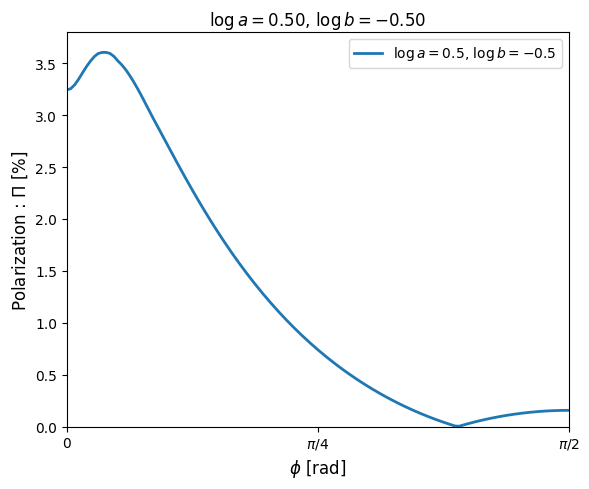

In [147]:
# ==========================================
# 1. Parameter Setup
# ==========================================
phi_list = np.linspace(0, np.pi/2, 129)

# Triaxial ellipsoid parameters
log_a = 0.5
log_b = -0.5
a = 10**log_a
b = 10**log_b

# Viewing angle (equator)
theta_view = np.pi / 2

# ==========================================
# 2. Calculation Loop
# ==========================================

nx = sin_Theta * cos_Phi / a**2
ny = sin_Theta * sin_Phi / b**2
nz = cos_Theta
n_array = np.stack([nx, ny, nz], axis=0)
n_array /= np.maximum(np.linalg.norm(n_array, axis=0, keepdims=True), 1e-12)

r2_array = 1.0 / ((sin_Theta * cos_Phi / a)**2 +
                  (sin_Theta * sin_Phi / b)**2 +
                  cos_Theta**2)

Pi_list = []
for phi in phi_list:
    I, Q, U = integrate_all_parameters(
    a, b, theta_view, phi,
    n_array, r2_array,
    w_Theta_array, dPhi,
    x_sphere, y_sphere, z_sphere
    )
    Pi = get_Pi(I, Q, U)
    Pi_list.append(Pi)

# ==========================================
# 3. Visualization
# ==========================================
fig, ax = plt.subplots(figsize=(6, 5))

# Plot the polarization curve
ax.plot(phi_list, Pi_list, linewidth=2.0,
        label=fr"$\log a={log_a}$, $\log b={log_b}$")

# Axes formatting
ax.set_xlabel(r"$\phi$ [rad]", fontsize=12)
ax.set_ylabel(r"Polarization : $\Pi$ [%]", fontsize=12)

ax.set_xlim(0.0, np.pi/2)
ax.set_ylim(0.0, 3.8)

# Custom x-ticks for radians
ax.set_xticks([0, np.pi/4, np.pi/2])
ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])

ax.set_title(fr"$\log a={current_log_a:.2f}$, $\log b={current_log_b:.2f}$", fontsize=12, pad=5)

# Add legend
ax.legend(loc="best", frameon=True)

plt.tight_layout()
plt.show()

### Figure 7 : The angular dependence of the polarization degree in the triaxial ellipsoid model

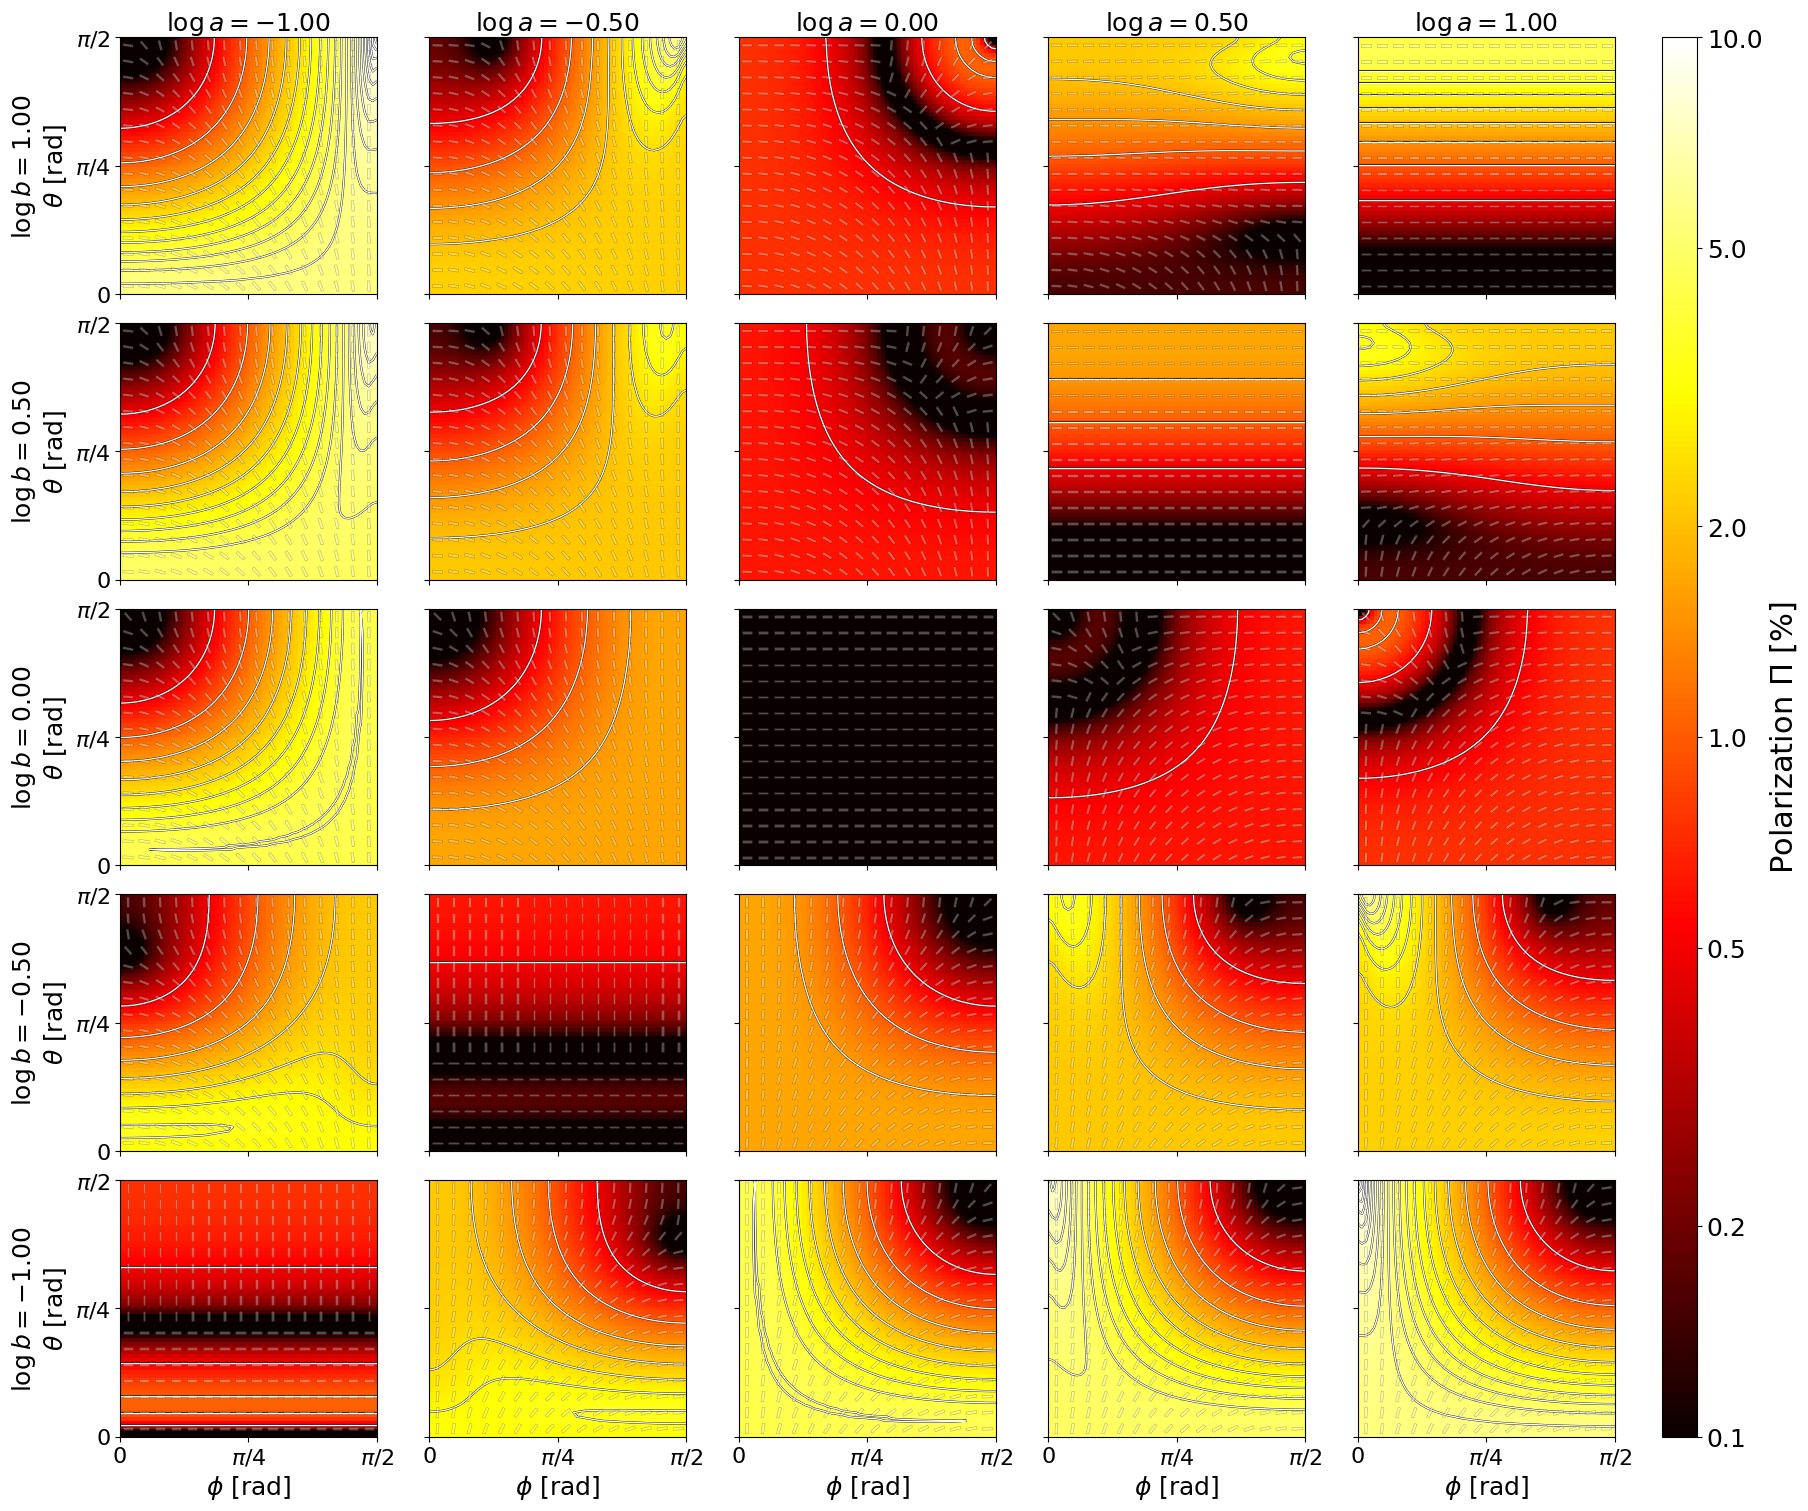

In [152]:
# ==========================================
# 1. Data Loading & Preprocessing
# ==========================================
filename = "ellipsoid_polarization_db_small.h5"

with h5py.File(filename, "r") as f:
    log_a_list = f["grid/log_a"][:]
    log_b_list = f["grid/log_b"][:]
    theta = f["grid/theta"][:]
    phi = f["grid/phi"][:]
    pi_data = f["Pi/values"][:]
    chi_data = f["chi/values"][:]

# Apply log10 safely by setting a minimum threshold
pi_min_threshold = 0.1
pi_data_log = np.log10(np.maximum(pi_data, pi_min_threshold))

# ==========================================
# 2. Grid Selection & Figure Setup
# ==========================================
a_indices = np.array([0, 1, 2, 3, 4])
b_indices = np.array([4, 3, 2, 1, 0])

na_sub = len(a_indices)
nb_sub = len(b_indices)

# constrained_layout handles the complex spacing automatically
fig, axes = plt.subplots(nb_sub, na_sub, figsize=(18, 15),
                         sharex=True, sharey=True, constrained_layout=True)

extent = [phi.min(), phi.max(), theta.min(), theta.max()]
Phi_grid, Theta_grid = np.meshgrid(Dphi, Dtheta)

# Define contour levels in linear and log scales
levels = np.arange(0.5, 10.5, 0.5)
levels_log = np.log10(levels)

# ==========================================
# 3. Multi-Panel Plotting Loop
# ==========================================
for i, ib in enumerate(b_indices):
    for j, ia in enumerate(a_indices):
        ax = axes[i, j]
        Z = pi_data_log[ia, ib, :, :]
        chi_slice = chi_data[ia, ib, :, :]

        # Heatmap
        im = ax.imshow(Z,
                       origin="lower",
                       extent=extent,
                       cmap="hot",
                       vmin=np.log10(0.1),
                       vmax=np.log10(10.0),
                       aspect="equal",  # Correct aspect for angle vs angle
                       interpolation="nearest")



        # Double Contour overlay for maximum contrast
        ax.contour(Phi_grid, Theta_grid, Z, levels=levels_log,
                   colors='black', linestyles="solid", linewidths=1.5,
                   zorder=1)
        ax.contour(Phi_grid, Theta_grid, Z, levels=levels_log,
                   colors='white', linestyles="solid", linewidths=1.0,
                   zorder=2)

        # Quiver Plot (Polarization vector field)
        Phi_grid, Theta_grid = np.meshgrid(phi, theta)

        # Subsampling step for the vector grid
        step = 4
        start = step // 2

        # Calculate vector components
        dir_X = np.sin(chi_slice)
        dir_Y = np.cos(chi_slice)

        # Plot line segments
        ax.quiver(Phi_grid[start::step, start::step], Theta_grid[start::step, start::step],
                  dir_X[start::step, start::step], dir_Y[start::step, start::step],
                  facecolors='white',
                  edgecolors='black',
                  pivot='mid',
                  headaxislength=0, headlength=0, headwidth=0,
                  width=0.01, linewidths=0.4,
                  scale=25, alpha=0.3,
                  zorder=3)

        # Formatting Ticks
        tick_positions = [0, np.pi/4, np.pi/2]
        tick_labels = ["0", r"$\pi/4$", r"$\pi/2$"]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(tick_labels)
        ax.tick_params(axis="both", labelsize=16)

        # Conditional Axes Labels & Titles
        if i == 0:
            ax.set_title(fr"$\log a = {log_a_list[ia]:.2f}$", fontsize=18, pad=5)
        if j == 0:
            ax.set_ylabel(fr"$\log b = {log_b_list[ib]:.2f}$" + "\n" + r"$\theta$ [rad]", fontsize=18)
        if i == nb_sub - 1:
            ax.set_xlabel(r"$\phi$ [rad]", fontsize=18)

# ==========================================
# 4. Global Colorbar
# ==========================================
cbar_labels = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
cbar_ticks = [np.log10(x) for x in cbar_labels]

# Attach colorbar to the entire axes grid
cbar = fig.colorbar(im, ax=axes, orientation='vertical', aspect=40, pad=0.02)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels(cbar_labels)
cbar.set_label(r'Polarization $\Pi$ [%]', fontsize=22)
cbar.ax.tick_params(labelsize=18)

plt.show()

### Figure 8 : Map of the maximum polarization degree as a function of the shape parameters log a and log b

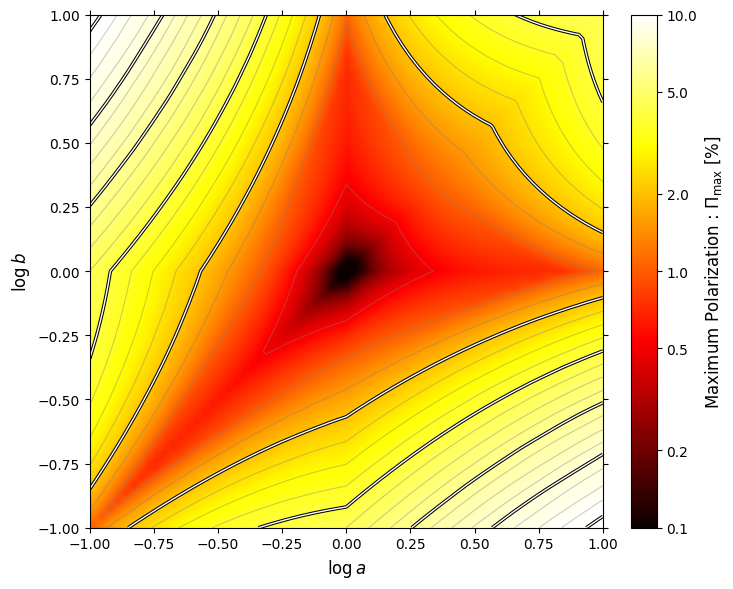

In [ ]:
# ==========================================
# 1. Data Loading & Preprocessing
# ==========================================
filename = "ellipsoid_polarization_maximum_db.h5"
with h5py.File(filename, "r") as f:
    log_a = f["grid/log_a"][:]
    log_b = f["grid/log_b"][:]
    Pi_max = f["Pi_max/value"][:]

# Safe lower bound for log10 calculation
Pi_min_threshold = 0.1
Pi_max_log = np.log10(np.maximum(Pi_max, Pi_min_threshold))

# ==========================================
# 3. Figure Setup & Heatmap
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

extent = [log_a.min(), log_a.max(), log_b.min(), log_b.max()]

# Heatmap setup
cp = ax.imshow(Pi_max_log.T,
               origin="lower",
               extent=extent,
               cmap="hot",
               vmin=np.log10(0.1),
               vmax=np.log10(10.0),
               aspect="equal",
               interpolation="bilinear")

# ==========================================
# 4. Contour Overlays
# ==========================================
# Explicit meshgrid to prevent coordinate misalignment
LogA_grid, LogB_grid = np.meshgrid(log_a, log_b)

# Minor contours (0.5 steps): Semi-transparent white
minor_levels = np.arange(0.5, 10.5, 0.5)
ax.contour(LogA_grid, LogB_grid, Pi_max.T,
           levels=minor_levels, colors='gray', linewidths=0.8, alpha=0.4)

# Major contours (2, 4, 6, 8, 10): Double lines for maximum visibility
major_levels = np.array([2.0, 4.0, 6.0, 8.0, 10.0])
ax.contour(LogA_grid, LogB_grid, Pi_max.T,
           levels=major_levels, colors='black', linewidths=2.5)
ax.contour(LogA_grid, LogB_grid, Pi_max.T,
           levels=major_levels, colors='white', linewidths=1.0)

# ==========================================
# 5. Axes Formatting
# ==========================================
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)

# Scientific journal style ticks (all sides)
ticks = [-1.0, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.tick_params(top=True, right=True)

ax.set_xlabel(r'$\log a$', fontsize=12)
ax.set_ylabel(r'$\log b$', fontsize=12)

# ==========================================
# 6. Colorbar Configuration
# ==========================================
# Alignment parameters to perfectly match the square axes height
cbar = fig.colorbar(cp, ax=ax, fraction=0.046, pad=0.04)

cbar_labels = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
cbar_ticks = [np.log10(x) for x in cbar_labels]

cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels(cbar_labels)
cbar.set_label(r'Maximum Polarization : $\Pi_{\rm max}$ [%]', fontsize=12)

plt.tight_layout()
plt.show()